In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
pd.options.display.max_columns = None

In [ ]:
#mouting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd drive/MyDrive/TFG/oulad

/content/drive/MyDrive/TFG/oulad


In [ ]:
df_final = pd.read_csv('dataset_date_cont.csv')

In [ ]:
df_final.head()

,Unnamed: 0,code_module,code_presentation,id_student,date_registration,date_unregistration,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,mean_score,total_clicks,clicks_from_forumng,clicks_from_homepage,clicks_from_oucontent,clicks_from_resource,clicks_from_subpage,clicks_from_url,clicks_from_externalquiz,clicks_from_oucollaborate,clicks_from_ouwiki,clicks_from_quiz,clicks_from_dataplus,clicks_from_glossary,clicks_from_page,clicks_from_dualpane,clicks_from_ouelluminate,clicks_from_htmlactivity,clicks_from_questionnaire,clicks_from_sharedsubpage,mean_clicks,continuous_grade,exam_grade,module_presentation_length,mean_clicks_per_day,Date,clicks_from_repeatactivity,clicks_from_folder
0,0,AAA,2013J,11391,-159.0,268.0,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0.0,301.0,20.0,31.0,221.0,8.0,20.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.688889,0.0,0.0,268,0.024959,15,NaN,NaN
1,1,AAA,2013J,28400,-53.0,268.0,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0.0,456.0,174.0,99.0,116.0,5.0,43.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.648000,0.0,0.0,268,0.013612,15,NaN,NaN
2,2,AAA,2013J,30268,-92.0,12.0,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,0.0,281.0,126.0,59.0,66.0,4.0,22.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.697368,0.0,0.0,268,0.013796,15,NaN,NaN
3,3,AAA,2013J,31604,-52.0,268.0,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0.0,349.0,97.0,65.0,125.0,10.0,38.0,13.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.835165,0.0,0.0,268,0.014310,15,NaN,NaN
4,4,AAA,2013J,32885,-176.0,268.0,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0.0,472.0,124.0,81.0,235.0,7.0,20.0,3.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.140351,0.0,0.0,268,0.015449,15,NaN,NaN


In [ ]:
#df_final.drop(['tma_mean_score', 'cma_mean_score', 'exam_mean_score'], axis=1, inplace=True)

In [ ]:
df_final['final_grade'] = df_final[['exam_grade', 'continuous_grade']].mean(axis=1)

In [ ]:
df_final.imd_band.value_counts()

20-30%     65772
30-40%     63702
10-20      63288
0-10%      59598
40-50%     58608
50-60%     56232
60-70%     52290
70-80%     51822
80-90%     49716
90-100%    45648
Name: imd_band, dtype: int64

In [ ]:
df_final['imd_band'] = df_final['imd_band'].replace(['0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'], [5, 15, 25, 35, 45, 55, 65, 75, 85, 95])

In [ ]:
df_final.imd_band.value_counts()

25.0    65772
35.0    63702
15.0    63288
5.0     59598
45.0    58608
55.0    56232
65.0    52290
75.0    51822
85.0    49716
95.0    45648
Name: imd_band, dtype: int64

In [ ]:
from sklearn.linear_model import LinearRegression

df_nans_imd = df_final.dropna(axis=0, subset=['imd_band', 'final_grade'])

X = df_nans_imd[['final_grade']]
y = df_nans_imd['imd_band']


missing_entries = df_final['imd_band'].isnull()
imd_missing = pd.DataFrame(df_final['final_grade'][missing_entries])

# fit a linear model
lm = LinearRegression().fit(X, y)
# use fitted model and tip values to predict missing total_bill
#pred_imd = lm.predict(imd_missing)

In [ ]:
lm.predict(np.array([9.0]).reshape(1, -1))[0]

/usr/local/lib/python3.9/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


46.071166088461645

In [ ]:
df_final.loc[pd.isna(df_final["imd_band"]), "imd_band"] = df_final[pd.isna(df_final["imd_band"])]["final_grade"].apply(
    lambda x: lm.predict(np.array([x]).reshape(1, -1))[0])

In [ ]:
df_final.imd_band.value_counts()

25.000000    65772
35.000000    63702
15.000000    63288
5.000000     59598
45.000000    58608
             ...  
46.977562        1
48.032487        1
46.170339        1
45.965074        1
51.193571        1
Name: imd_band, Length: 3186, dtype: int64

In [ ]:
def round_to_nearest_five(num):
    """
    Rounds the given number to the nearest number ending in 5 if the number does not already end in 5.
    """
    if num % 10 == 5:
        return num
    quotient, remainder = divmod(num, 10)
    if remainder < 3:
        return quotient * 10 + 5
    else:
        return (quotient + 1) * 10 + 5


In [ ]:
df_final.imd_band=df_final.imd_band.apply(lambda x: round_to_nearest_five(x))

In [ ]:
df_final.imd_band.value_counts()

55.0    74899
25.0    65772
35.0    63702
15.0    63288
5.0     59598
45.0    58608
65.0    53621
75.0    51822
85.0    49716
95.0    45648
Name: imd_band, dtype: int64

In [ ]:
df_final

,Unnamed: 0,code_module,code_presentation,id_student,date_registration,date_unregistration,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,mean_score,total_clicks,clicks_from_forumng,clicks_from_homepage,clicks_from_oucontent,clicks_from_resource,clicks_from_subpage,clicks_from_url,clicks_from_externalquiz,clicks_from_oucollaborate,clicks_from_ouwiki,clicks_from_quiz,clicks_from_dataplus,clicks_from_glossary,clicks_from_page,clicks_from_dualpane,clicks_from_ouelluminate,clicks_from_htmlactivity,clicks_from_questionnaire,clicks_from_sharedsubpage,mean_clicks,continuous_grade,exam_grade,module_presentation_length,mean_clicks_per_day,Date,clicks_from_repeatactivity,clicks_from_folder,final_grade
0,0,AAA,2013J,11391,-159.0,268.0,M,East Anglian Region,HE Qualification,95.0,55<=,0,240,N,Pass,0.000000,301.0,20.0,31.0,221.0,8.0,20.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.688889,0.00,0.00,268,0.024959,15,NaN,NaN,0.00
1,1,AAA,2013J,28400,-53.0,268.0,F,Scotland,HE Qualification,25.0,35-55,0,60,N,Pass,0.000000,456.0,174.0,99.0,116.0,5.0,43.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.648000,0.00,0.00,268,0.013612,15,NaN,NaN,0.00
2,2,AAA,2013J,30268,-92.0,12.0,F,North Western Region,A Level or Equivalent,35.0,35-55,0,60,Y,Withdrawn,0.000000,281.0,126.0,59.0,66.0,4.0,22.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.697368,0.00,0.00,268,0.013796,15,NaN,NaN,0.00
3,3,AAA,2013J,31604,-52.0,268.0,F,South East Region,A Level or Equivalent,55.0,35-55,0,60,N,Pass,0.000000,349.0,97.0,65.0,125.0,10.0,38.0,13.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.835165,0.00,0.00,268,0.014310,15,NaN,NaN,0.00
4,4,AAA,2013J,32885,-176.0,268.0,F,West Midlands Region,Lower Than A Level,55.0,0-35,0,60,N,Pass,0.000000,472.0,124.0,81.0,235.0,7.0,20.0,3.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.140351,0.00,0.00,268,0.015449,15,NaN,NaN,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586669,32588,GGG,2014J,2640965,-4.0,269.0,F,Wales,Lower Than A Level,15.0,0-35,0,30,N,Fail,0.000000,41.0,0.0,22.0,6.0,4.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.157895,0.00,0.00,269,0.008022,270,0.0,0.0,0.00
586670,32589,GGG,2014J,2645731,-23.0,269.0,F,East Anglian Region,Lower Than A Level,45.0,35-55,0,30,N,Distinction,88.111111,893.0,65.0,167.0,348.0,109.0,47.0,0.0,0.0,0.0,0.0,152.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,3.767932,87.23,87.23,269,0.014007,270,0.0,0.0,87.23
586671,32590,GGG,2014J,2648187,-129.0,269.0,F,South Region,A Level or Equivalent,25.0,0-35,0,30,Y,Pass,76.666667,312.0,0.0,63.0,79.0,19.0,20.0,0.0,0.0,0.0,0.0,130.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.888889,75.90,75.90,269,0.010739,270,0.0,0.0,75.90
586672,32591,GGG,2014J,2679821,-49.0,101.0,F,South East Region,Lower Than A Level,95.0,35-55,0,30,N,Withdrawn,91.500000,275.0,118.0,65.0,40.0,9.0,12.0,0.0,0.0,0.0,0.0,31.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.508197,20.13,20.13,269,0.016759,270,0.0,0.0,20.13


In [1]:
df_final['gender'] = df_final['gender'].map({'M': 0,'F': 1})

NameError: ignored

In [ ]:
df_final['disability'] = df_final['disability'].map({'N': 0,'Y': 1})

In [ ]:
df_final.columns

Index(['Unnamed: 0', 'code_module', 'code_presentation', 'id_student',
       'date_registration', 'date_unregistration', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'mean_score',
       'total_clicks', 'clicks_from_forumng', 'clicks_from_homepage',
       'clicks_from_oucontent', 'clicks_from_resource', 'clicks_from_subpage',
       'clicks_from_url', 'clicks_from_externalquiz',
       'clicks_from_oucollaborate', 'clicks_from_ouwiki', 'clicks_from_quiz',
       'clicks_from_dataplus', 'clicks_from_glossary', 'clicks_from_page',
       'clicks_from_dualpane', 'clicks_from_ouelluminate',
       'clicks_from_htmlactivity', 'clicks_from_questionnaire',
       'clicks_from_sharedsubpage', 'mean_clicks', 'continuous_grade',
       'exam_grade', 'module_presentation_length', 'mean_clicks_per_day',
       'Date', 'clicks_from_repeatactivity', 'clicks_from_folder',
       'final_grade']

In [ ]:
df_final.code_module.value_counts()

BBB    142362
FFF    139716
DDD    112896
CCC     79812
EEE     52812
GGG     45612
AAA     13464
Name: code_module, dtype: int64

In [ ]:
df_final['code_module']

0         AAA
1         AAA
2         AAA
3         AAA
4         AAA
         ... 
586669    GGG
586670    GGG
586671    GGG
586672    GGG
586673    GGG
Name: code_module, Length: 586674, dtype: object

In [ ]:
df_final = pd.get_dummies(df_final, prefix="code_module", 
                            columns=["code_module"], 
                            drop_first=False)
df_final.head()

,Unnamed: 0,code_presentation,id_student,date_registration,date_unregistration,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,mean_score,total_clicks,clicks_from_forumng,clicks_from_homepage,clicks_from_oucontent,clicks_from_resource,clicks_from_subpage,clicks_from_url,clicks_from_externalquiz,clicks_from_oucollaborate,clicks_from_ouwiki,clicks_from_quiz,clicks_from_dataplus,clicks_from_glossary,clicks_from_page,clicks_from_dualpane,clicks_from_ouelluminate,clicks_from_htmlactivity,clicks_from_questionnaire,clicks_from_sharedsubpage,mean_clicks,continuous_grade,exam_grade,module_presentation_length,mean_clicks_per_day,Date,clicks_from_repeatactivity,clicks_from_folder,final_grade,code_module_AAA,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG
0,0,2013J,11391,-159.0,268.0,0,East Anglian Region,HE Qualification,95.0,55<=,0,240,0,Pass,0.0,301.0,20.0,31.0,221.0,8.0,20.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.688889,0.0,0.0,268,0.024959,15,NaN,NaN,0.0,1,0,0,0,0,0,0
1,1,2013J,28400,-53.0,268.0,1,Scotland,HE Qualification,25.0,35-55,0,60,0,Pass,0.0,456.0,174.0,99.0,116.0,5.0,43.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.648000,0.0,0.0,268,0.013612,15,NaN,NaN,0.0,1,0,0,0,0,0,0
2,2,2013J,30268,-92.0,12.0,1,North Western Region,A Level or Equivalent,35.0,35-55,0,60,1,Withdrawn,0.0,281.0,126.0,59.0,66.0,4.0,22.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.697368,0.0,0.0,268,0.013796,15,NaN,NaN,0.0,1,0,0,0,0,0,0
3,3,2013J,31604,-52.0,268.0,1,South East Region,A Level or Equivalent,55.0,35-55,0,60,0,Pass,0.0,349.0,97.0,65.0,125.0,10.0,38.0,13.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.835165,0.0,0.0,268,0.014310,15,NaN,NaN,0.0,1,0,0,0,0,0,0
4,4,2013J,32885,-176.0,268.0,1,West Midlands Region,Lower Than A Level,55.0,0-35,0,60,0,Pass,0.0,472.0,124.0,81.0,235.0,7.0,20.0,3.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.140351,0.0,0.0,268,0.015449,15,NaN,NaN,0.0,1,0,0,0,0,0,0


In [ ]:
df_final.head()

,Unnamed: 0,code_presentation,id_student,date_registration,date_unregistration,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,mean_score,total_clicks,clicks_from_forumng,clicks_from_homepage,clicks_from_oucontent,clicks_from_resource,clicks_from_subpage,clicks_from_url,clicks_from_externalquiz,clicks_from_oucollaborate,clicks_from_ouwiki,clicks_from_quiz,clicks_from_dataplus,clicks_from_glossary,clicks_from_page,clicks_from_dualpane,clicks_from_ouelluminate,clicks_from_htmlactivity,clicks_from_questionnaire,clicks_from_sharedsubpage,mean_clicks,continuous_grade,exam_grade,module_presentation_length,mean_clicks_per_day,Date,clicks_from_repeatactivity,clicks_from_folder,final_grade,code_module_AAA,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG
0,0,2013J,11391,-159.0,268.0,0,East Anglian Region,HE Qualification,95.0,55<=,0,240,0,Pass,0.0,301.0,20.0,31.0,221.0,8.0,20.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.688889,0.0,0.0,268,0.024959,15,NaN,NaN,0.0,1,0,0,0,0,0,0
1,1,2013J,28400,-53.0,268.0,1,Scotland,HE Qualification,25.0,35-55,0,60,0,Pass,0.0,456.0,174.0,99.0,116.0,5.0,43.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.648000,0.0,0.0,268,0.013612,15,NaN,NaN,0.0,1,0,0,0,0,0,0
2,2,2013J,30268,-92.0,12.0,1,North Western Region,A Level or Equivalent,35.0,35-55,0,60,1,Withdrawn,0.0,281.0,126.0,59.0,66.0,4.0,22.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.697368,0.0,0.0,268,0.013796,15,NaN,NaN,0.0,1,0,0,0,0,0,0
3,3,2013J,31604,-52.0,268.0,1,South East Region,A Level or Equivalent,55.0,35-55,0,60,0,Pass,0.0,349.0,97.0,65.0,125.0,10.0,38.0,13.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.835165,0.0,0.0,268,0.014310,15,NaN,NaN,0.0,1,0,0,0,0,0,0
4,4,2013J,32885,-176.0,268.0,1,West Midlands Region,Lower Than A Level,55.0,0-35,0,60,0,Pass,0.0,472.0,124.0,81.0,235.0,7.0,20.0,3.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.140351,0.0,0.0,268,0.015449,15,NaN,NaN,0.0,1,0,0,0,0,0,0


In [ ]:
df_final = pd.get_dummies(df_final, prefix="code_presentation", 
                            columns=["code_presentation"], 
                            drop_first=False)
df_final.head()

,Unnamed: 0,id_student,date_registration,date_unregistration,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,mean_score,total_clicks,clicks_from_forumng,clicks_from_homepage,clicks_from_oucontent,clicks_from_resource,clicks_from_subpage,clicks_from_url,clicks_from_externalquiz,clicks_from_oucollaborate,clicks_from_ouwiki,clicks_from_quiz,clicks_from_dataplus,clicks_from_glossary,clicks_from_page,clicks_from_dualpane,clicks_from_ouelluminate,clicks_from_htmlactivity,clicks_from_questionnaire,clicks_from_sharedsubpage,mean_clicks,continuous_grade,exam_grade,module_presentation_length,mean_clicks_per_day,Date,clicks_from_repeatactivity,clicks_from_folder,final_grade,code_module_AAA,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013B,code_presentation_2013J,code_presentation_2014B,code_presentation_2014J
0,0,11391,-159.0,268.0,0,East Anglian Region,HE Qualification,95.0,55<=,0,240,0,Pass,0.0,301.0,20.0,31.0,221.0,8.0,20.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.688889,0.0,0.0,268,0.024959,15,NaN,NaN,0.0,1,0,0,0,0,0,0,0,1,0,0
1,1,28400,-53.0,268.0,1,Scotland,HE Qualification,25.0,35-55,0,60,0,Pass,0.0,456.0,174.0,99.0,116.0,5.0,43.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.648000,0.0,0.0,268,0.013612,15,NaN,NaN,0.0,1,0,0,0,0,0,0,0,1,0,0
2,2,30268,-92.0,12.0,1,North Western Region,A Level or Equivalent,35.0,35-55,0,60,1,Withdrawn,0.0,281.0,126.0,59.0,66.0,4.0,22.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.697368,0.0,0.0,268,0.013796,15,NaN,NaN,0.0,1,0,0,0,0,0,0,0,1,0,0
3,3,31604,-52.0,268.0,1,South East Region,A Level or Equivalent,55.0,35-55,0,60,0,Pass,0.0,349.0,97.0,65.0,125.0,10.0,38.0,13.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.835165,0.0,0.0,268,0.014310,15,NaN,NaN,0.0,1,0,0,0,0,0,0,0,1,0,0
4,4,32885,-176.0,268.0,1,West Midlands Region,Lower Than A Level,55.0,0-35,0,60,0,Pass,0.0,472.0,124.0,81.0,235.0,7.0,20.0,3.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.140351,0.0,0.0,268,0.015449,15,NaN,NaN,0.0,1,0,0,0,0,0,0,0,1,0,0


In [ ]:
df_final = pd.get_dummies(df_final, prefix="region", 
                            columns=["region"], 
                            drop_first=False)
df_final.head()

,Unnamed: 0,id_student,date_registration,date_unregistration,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,mean_score,total_clicks,clicks_from_forumng,clicks_from_homepage,clicks_from_oucontent,clicks_from_resource,clicks_from_subpage,clicks_from_url,clicks_from_externalquiz,clicks_from_oucollaborate,clicks_from_ouwiki,clicks_from_quiz,clicks_from_dataplus,clicks_from_glossary,clicks_from_page,clicks_from_dualpane,clicks_from_ouelluminate,clicks_from_htmlactivity,clicks_from_questionnaire,clicks_from_sharedsubpage,mean_clicks,continuous_grade,exam_grade,module_presentation_length,mean_clicks_per_day,Date,clicks_from_repeatactivity,clicks_from_folder,final_grade,code_module_AAA,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013B,code_presentation_2013J,code_presentation_2014B,code_presentation_2014J,region_East Anglian Region,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region
0,0,11391,-159.0,268.0,0,HE Qualification,95.0,55<=,0,240,0,Pass,0.0,301.0,20.0,31.0,221.0,8.0,20.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.688889,0.0,0.0,268,0.024959,15,NaN,NaN,0.0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,1,28400,-53.0,268.0,1,HE Qualification,25.0,35-55,0,60,0,Pass,0.0,456.0,174.0,99.0,116.0,5.0,43.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.648000,0.0,0.0,268,0.013612,15,NaN,NaN,0.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,2,30268,-92.0,12.0,1,A Level or Equivalent,35.0,35-55,0,60,1,Withdrawn,0.0,281.0,126.0,59.0,66.0,4.0,22.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.697368,0.0,0.0,268,0.013796,15,NaN,NaN,0.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
3,3,31604,-52.0,268.0,1,A Level or Equivalent,55.0,35-55,0,60,0,Pass,0.0,349.0,97.0,65.0,125.0,10.0,38.0,13.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.835165,0.0,0.0,268,0.014310,15,NaN,NaN,0.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,4,32885,-176.0,268.0,1,Lower Than A Level,55.0,0-35,0,60,0,Pass,0.0,472.0,124.0,81.0,235.0,7.0,20.0,3.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.140351,0.0,0.0,268,0.015449,15,NaN,NaN,0.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [ ]:
df_final['highest_education'] = df_final['highest_education'].map({'No Formal quals': 0,'Lower Than A Level': 1, 'A Level or Equivalent': 2, 'HE Qualification': 3, 'Post Graduate Qualification': 4})

In [ ]:
df_final.age_band.value_counts()

0-35     412992
35-55    169794
55<=       3888
Name: age_band, dtype: int64

In [ ]:
df_final['age_band'] = df_final['age_band'].map({'0-35': 0,'35-55': 1, '55<=':2})

In [ ]:
df_final.final_result.value_counts()

Pass           222498
Withdrawn      182808
Fail           126936
Distinction     54432
Name: final_result, dtype: int64

In [ ]:
df_final['result_stays']=df_final.final_result

In [ ]:
df_final['result_aprueba']=df_final.final_result

In [ ]:
df_final['result_stays'] = df_final['result_stays'].map({'Pass': 1,'Withdrawn': 0, 'Fail':1, 'Distinction': 0})

In [ ]:
df_final['result_aprueba'] = df_final['result_aprueba'].map({'Pass': 1,'Withdrawn': 2, 'Fail':0, 'Distinction': 1})

In [ ]:
#df_final['final_result']

In [ ]:
df_final.fillna(0, inplace=True)

In [ ]:
pd.options.display.min_rows = 115
df_final.isnull().sum()

Unnamed: 0                     0
id_student                     0
date_registration              0
date_unregistration            0
gender                         0
highest_education              0
imd_band                       0
age_band                       0
num_of_prev_attempts           0
studied_credits                0
disability                     0
final_result                   0
mean_score                     0
total_clicks                   0
clicks_from_forumng            0
clicks_from_homepage           0
clicks_from_oucontent          0
clicks_from_resource           0
clicks_from_subpage            0
clicks_from_url                0
clicks_from_externalquiz       0
clicks_from_oucollaborate      0
clicks_from_ouwiki             0
clicks_from_quiz               0
clicks_from_dataplus           0
clicks_from_glossary           0
clicks_from_page               0
clicks_from_dualpane           0
clicks_from_ouelluminate       0
clicks_from_htmlactivity       0
          

In [ ]:
df_won=df_final.copy()
del df_won['final_result']
del df_won['result_aprueba']

In [ ]:
df_final

,Unnamed: 0,id_student,date_registration,date_unregistration,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,mean_score,total_clicks,clicks_from_forumng,clicks_from_homepage,clicks_from_oucontent,clicks_from_resource,clicks_from_subpage,clicks_from_url,clicks_from_externalquiz,clicks_from_oucollaborate,clicks_from_ouwiki,clicks_from_quiz,clicks_from_dataplus,clicks_from_glossary,clicks_from_page,clicks_from_dualpane,clicks_from_ouelluminate,clicks_from_htmlactivity,clicks_from_questionnaire,clicks_from_sharedsubpage,mean_clicks,continuous_grade,exam_grade,module_presentation_length,mean_clicks_per_day,Date,clicks_from_repeatactivity,clicks_from_folder,final_grade,code_module_AAA,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013B,code_presentation_2013J,code_presentation_2014B,code_presentation_2014J,region_East Anglian Region,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,result_stays,result_aprueba
0,0,11391,-159.0,268.0,0,3,95.0,2,0,240,0,Pass,0.000000,301.0,20.0,31.0,221.0,8.0,20.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.688889,0.00,0.00,268,0.024959,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1
1,1,28400,-53.0,268.0,1,3,25.0,1,0,60,0,Pass,0.000000,456.0,174.0,99.0,116.0,5.0,43.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.648000,0.00,0.00,268,0.013612,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1
2,2,30268,-92.0,12.0,1,2,35.0,1,0,60,1,Withdrawn,0.000000,281.0,126.0,59.0,66.0,4.0,22.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.697368,0.00,0.00,268,0.013796,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,2
3,3,31604,-52.0,268.0,1,2,55.0,1,0,60,0,Pass,0.000000,349.0,97.0,65.0,125.0,10.0,38.0,13.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.835165,0.00,0.00,268,0.014310,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1
4,4,32885,-176.0,268.0,1,1,55.0,0,0,60,0,Pass,0.000000,472.0,124.0,81.0,235.0,7.0,20.0,3.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.140351,0.00,0.00,268,0.015449,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1
5,5,38053,-110.0,268.0,0,2,85.0,1,0,60,0,Pass,0.000000,580.0,285.0,131.0,132.0,6.0,21.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.000000,0.00,0.00,268,0.014925,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1
6,6,45462,-67.0,268.0,0,3,35.0,0,0,60,0,Pass,0.000000,254.0,23.0,45.0,156.0,4.0,19.0,5.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.183673,0.00,0.00,268,0.019342,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1
7,7,45642,-29.0,268.0,1,2,95.0,0,0,120,0,Pass,0.000000,167.0,66.0,37.0,44.0,2.0,12.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.420290,0.00,0.00,268,0.009031,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1
8,8,52130,-33.0,268.0,1,2,75.0,0,0,90,0,Pass,0.000000,110.0,35.0,37.0,19.0,1.0,11.0,5.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,0.00,0.00,268,0.007463,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1
9,9,53025,-179.0,268.0,0,4,55.0,2,0,60,0,Pass,71.000000,382.0,154.0,42.0,143.0,4.0,28.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.745098,7.10,0.00,268,0.013974,15,0.0,0.0,3.55,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1


In [ ]:
X = df_won.copy()
y = X.pop("result_stays")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.4, random_state=25)

# Normalizing the data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to np arrays
Y_train =  Y_train.values
Y_test =  Y_test.values

In [ ]:
from sklearn.feature_selection import mutual_info_regression
mi_scores = mutual_info_regression(X_train, Y_train)
ind_rel_feat = np.argsort(mi_scores)[::-1]
mi_scores = pd.Series(mi_scores[ind_rel_feat], index =X.columns[ind_rel_feat])

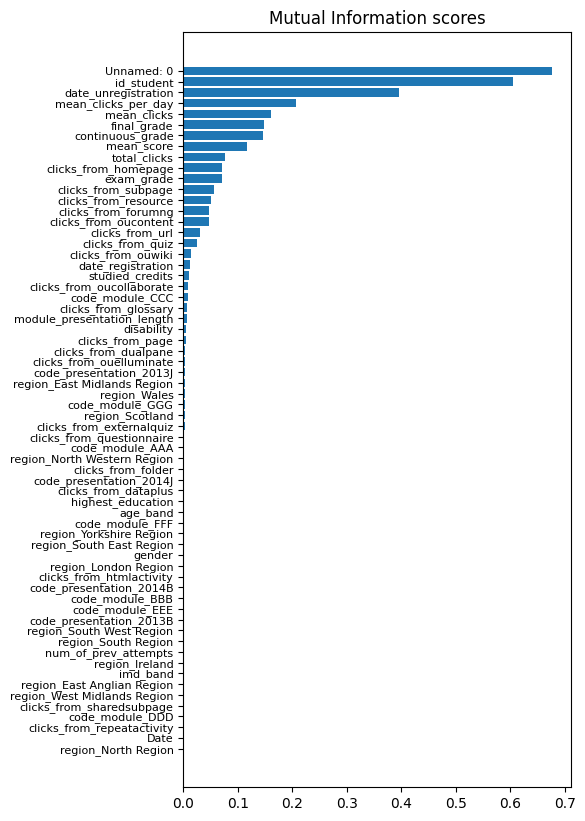

In [ ]:
def plot_utility_scores(scores, title):
    y = scores.sort_values(ascending=True)
    width = np.arange(len(y))
    ticks = list(y.index)
    plt.barh(width, y)
    plt.yticks(width, ticks)
    plt.title(title)

plt.figure(dpi=100, figsize=(5, 10))
plt.rc('ytick', labelsize=8)
plot_utility_scores(mi_scores, title="Mutual Information scores")

In [ ]:
# Variable initialization
n_var = X_train.shape[1]
var_sel = np.empty(0,dtype=int) # subset of selected features
var_cand = np.arange(n_var) # subset of candidate features

# Precompute relevances 
relevances = mutual_info_regression(X_train, Y_train)

# Precomupute redundancies (correlation among all input variables, it is a matrix of n_var x n_var)
redundancies = np.abs(np.cov(X_train.T))

# Select the most relevant feature
sel = np.argmax(relevances)
# Add it to the subset of selected features
var_sel = np.hstack([var_sel,sel])
# Remove it from the subset of candidate features
var_cand = np.delete(var_cand,sel)

MRmr_values= [relevances[sel]]

# Iteratively select variables
for i in range(n_var-1):
    # Get relevance values of the var_cand variables
    relevances_cand=relevances[var_cand]
    
    # Compute redundancies with selected features:
    # from the redundancies matrix select the rows of var_sel and the columns of var_cand
    redundancy_sel = redundancies[np.ix_(var_sel,var_cand)]    
    # Average the redundancy values over the selected features (rows) 
    # to get a redundancy value for each candidate variables   
    redundancy_cand=np.mean(redundancy_sel,axis=0)
    
    # Compute MRmr = relevances_cand - redundancy_cand
    MRmr=relevances_cand-redundancy_cand
    
    # Select the new feature as the one with the maximum MRmr value
    sel=np.argmax(MRmr)
    MRmr_values.append(MRmr[sel])
    # Add it to the subset of selected features
    var_sel=np.hstack([var_sel,var_cand[sel]])
    # Remove it from the subset of candidate features
    var_cand= np.delete(var_cand,sel)

ind_rel_feat = var_sel

In [ ]:
mi_scores_MRmr = pd.Series(MRmr_values, index =X.columns[ind_rel_feat])
mi_scores_MRmr

Unnamed: 0                     0.675013
id_student                     0.602618
date_unregistration            0.392958
mean_clicks_per_day            0.207378
mean_clicks                    0.158033
final_grade                    0.143281
continuous_grade               0.131854
mean_score                     0.094681
total_clicks                   0.076117
clicks_from_homepage           0.068015
clicks_from_subpage            0.053466
exam_grade                     0.052021
clicks_from_resource           0.048548
clicks_from_forumng            0.047014
clicks_from_oucontent          0.045801
clicks_from_url                0.030941
clicks_from_quiz               0.025002
studied_credits                0.012510
clicks_from_ouwiki             0.012301
date_registration              0.010853
clicks_from_oucollaborate      0.007044
clicks_from_glossary           0.006671
clicks_from_dualpane           0.005035
clicks_from_externalquiz       0.004399
clicks_from_ouelluminate       0.003955


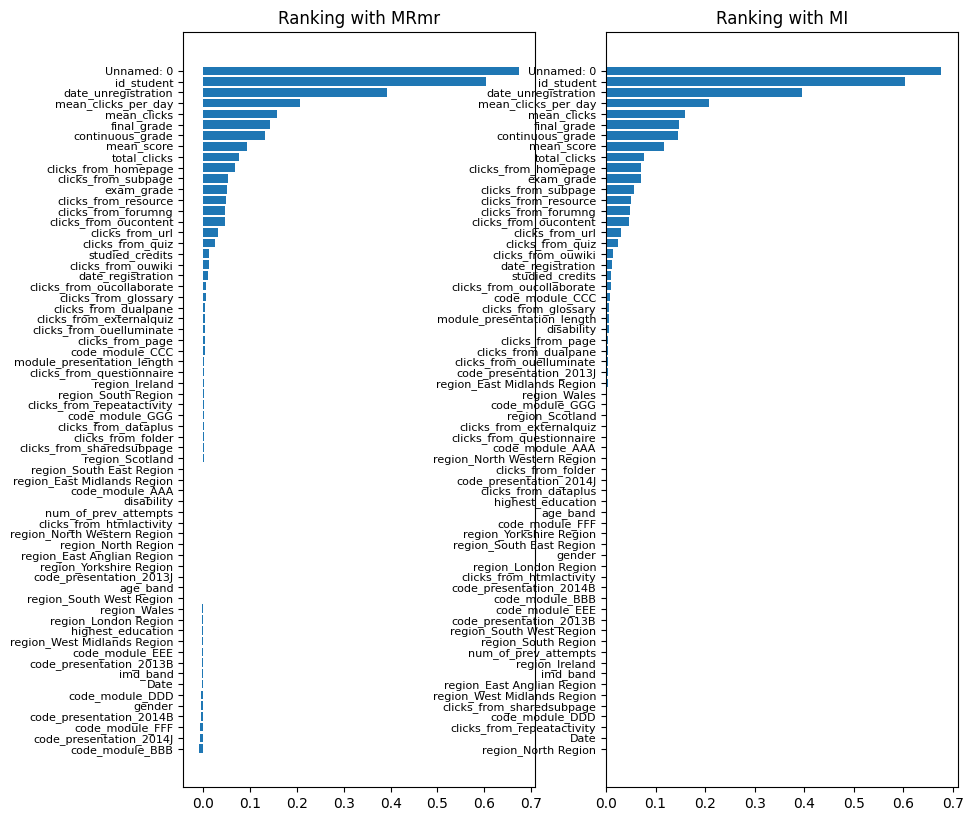

In [ ]:
plt.figure(dpi=100, figsize=(10, 10))
plt.subplot(1,2,1)
plt.rc('ytick', labelsize=8)
plot_utility_scores(mi_scores_MRmr, title="Ranking with MRmr")
plt.subplot(1,2,2)
plot_utility_scores(mi_scores, title="Ranking with MI")
#nos quedamos con los clicks de homepage, resource, subpage, outcontent, forum, url, quiz, glossary, wiki, questionarie, dataplus

In [ ]:
df_won.corr()[['result_stays']].sort_values(by='result_stays', ascending=False)

,result_stays
result_stays,1.000000e+00
date_unregistration,7.246764e-01
mean_score,3.290675e-01
continuous_grade,2.925123e-01
final_grade,2.537236e-01
mean_clicks_per_day,2.435958e-01
mean_clicks,2.420821e-01
exam_grade,1.880542e-01
clicks_from_subpage,1.383924e-01
total_clicks,1.359785e-01


In [ ]:
del df_final['final_result']

In [ ]:
df_final

,Unnamed: 0,id_student,date_registration,date_unregistration,gender,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,mean_score,total_clicks,clicks_from_forumng,clicks_from_homepage,clicks_from_oucontent,clicks_from_resource,clicks_from_subpage,clicks_from_url,clicks_from_externalquiz,clicks_from_oucollaborate,clicks_from_ouwiki,clicks_from_quiz,clicks_from_dataplus,clicks_from_glossary,clicks_from_page,clicks_from_dualpane,clicks_from_ouelluminate,clicks_from_htmlactivity,clicks_from_questionnaire,clicks_from_sharedsubpage,mean_clicks,continuous_grade,exam_grade,module_presentation_length,mean_clicks_per_day,Date,clicks_from_repeatactivity,clicks_from_folder,final_grade,code_module_AAA,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013B,code_presentation_2013J,code_presentation_2014B,code_presentation_2014J,region_East Anglian Region,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,result_stays,result_aprueba
0,0,11391,-159.0,268.0,0,3,95.0,2,0,240,0,0.000000,301.0,20.0,31.0,221.0,8.0,20.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.688889,0.00,0.00,268,0.024959,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1
1,1,28400,-53.0,268.0,1,3,25.0,1,0,60,0,0.000000,456.0,174.0,99.0,116.0,5.0,43.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.648000,0.00,0.00,268,0.013612,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1
2,2,30268,-92.0,12.0,1,2,35.0,1,0,60,1,0.000000,281.0,126.0,59.0,66.0,4.0,22.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.697368,0.00,0.00,268,0.013796,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,2
3,3,31604,-52.0,268.0,1,2,55.0,1,0,60,0,0.000000,349.0,97.0,65.0,125.0,10.0,38.0,13.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.835165,0.00,0.00,268,0.014310,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1
4,4,32885,-176.0,268.0,1,1,55.0,0,0,60,0,0.000000,472.0,124.0,81.0,235.0,7.0,20.0,3.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.140351,0.00,0.00,268,0.015449,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1
5,5,38053,-110.0,268.0,0,2,85.0,1,0,60,0,0.000000,580.0,285.0,131.0,132.0,6.0,21.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.000000,0.00,0.00,268,0.014925,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1
6,6,45462,-67.0,268.0,0,3,35.0,0,0,60,0,0.000000,254.0,23.0,45.0,156.0,4.0,19.0,5.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.183673,0.00,0.00,268,0.019342,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1
7,7,45642,-29.0,268.0,1,2,95.0,0,0,120,0,0.000000,167.0,66.0,37.0,44.0,2.0,12.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.420290,0.00,0.00,268,0.009031,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1
8,8,52130,-33.0,268.0,1,2,75.0,0,0,90,0,0.000000,110.0,35.0,37.0,19.0,1.0,11.0,5.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,0.00,0.00,268,0.007463,15,0.0,0.0,0.00,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1
9,9,53025,-179.0,268.0,0,4,55.0,2,0,60,0,71.000000,382.0,154.0,42.0,143.0,4.0,28.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.745098,7.10,0.00,268,0.013974,15,0.0,0.0,3.55,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1


In [ ]:
#df_final.to_csv('dataset_numerical.csv')